<a href="https://colab.research.google.com/github/sellyrk/Analisis-Pengaruh-Perubahan-Tahun-terhadap-Produksi-Pertanian-di-Indonesia/blob/main/Kel_4_Padi_RM_MANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KELOMPOK 4_DATA PADI_RM MANOVA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial.distance import mahalanobis
from scipy.linalg import det
from scipy.spatial.distance import mahalanobis

## Memanggil Dataset

In [ ]:
df = pd.read_csv('/content/StatMul Dataset - Data baru.csv')
df.head()

,Provinsi,Tahun,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
0,ACEH,2024,"301196,35","55,11","1659966,28"
1,SUMATERA UTARA,2024,"419463,48","52,56","2204875,51"
2,SUMATERA BARAT,2024,"295278,98","45,94","1356467,93"
3,RIAU,2024,"56421,96","39,36","222055,71"
4,JAMBI,2024,"61625,68","45,6","281022,05"


## Mengetahui Informasi Dataset

In [ ]:
df.columns

Index(['Provinsi', 'Tahun', 'Luas Panen (ha)', 'Produktivitas (ku/ha)',
       'Produksi (ton)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Provinsi               190 non-null    object
 1   Tahun                  190 non-null    int64 
 2   Luas Panen (ha)        190 non-null    object
 3   Produktivitas (ku/ha)  190 non-null    object
 4   Produksi (ton)         190 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.6+ KB


In [ ]:
df.dtypes

,0
Provinsi,object
Tahun,int64
Luas Panen (ha),object
Produktivitas (ku/ha),object
Produksi (ton),object


## Mengubah tipe data

In [ ]:
df["Luas Panen (ha)"] = df["Luas Panen (ha)"].str.replace(",", ".").astype(float).astype(int)
df["Produktivitas (ku/ha)"] = df["Produktivitas (ku/ha)"].str.replace(",", ".").astype(float)  # Tetap float karena mungkin desimal
df["Produksi (ton)"] = df["Produksi (ton)"].str.replace(",", ".").astype(float).astype(int)

df

,Provinsi,Tahun,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
0,ACEH,2024,301196,55.11,1659966
1,SUMATERA UTARA,2024,419463,52.56,2204875
2,SUMATERA BARAT,2024,295278,45.94,1356467
3,RIAU,2024,56421,39.36,222055
4,JAMBI,2024,61625,45.60,281022
...,...,...,...,...,...
185,PAPUA BARAT DAYA,2020,0,0.00,0
186,PAPUA,2020,52727,31.48,166002
187,PAPUA SELATAN,2020,0,0.00,0
188,PAPUA TENGAH,2020,0,0.00,0


## Menghapus Variabel Tidak Berpengaruh

In [ ]:
df = df.drop(columns=["Provinsi"])
df

,Tahun,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
0,2024,301196,55.11,1659966
1,2024,419463,52.56,2204875
2,2024,295278,45.94,1356467
3,2024,56421,39.36,222055
4,2024,61625,45.60,281022
...,...,...,...,...
185,2020,0,0.00,0
186,2020,52727,31.48,166002
187,2020,0,0.00,0
188,2020,0,0.00,0


## Menyesuaikan distribusi data dengan logaritmik

In [ ]:
df["Luas Panen (ha)"] = np.log1p(df["Luas Panen (ha)"])
df["Produktivitas (ku/ha)"] = np.log1p(df["Produktivitas (ku/ha)"])
df["Produksi (ton)"] = np.log1p(df["Produksi (ton)"])

df

,Tahun,Luas Panen (ha),Produktivitas (ku/ha),Produksi (ton)
0,2024,12.615520,4.027314,14.322308
1,2024,12.946733,3.980803,14.606182
2,2024,12.595676,3.848870,14.120395
3,2024,10.940614,3.697839,12.310685
4,2024,11.028839,3.841601,12.546192
...,...,...,...,...
185,2020,0.000000,0.000000,0.000000
186,2020,10.872902,3.480625,12.019761
187,2020,0.000000,0.000000,0.000000
188,2020,0.000000,0.000000,0.000000


## Uji Asumsi Independen

In [ ]:
# Pilih fitur numerik untuk uji Bartlett
# data = df.iloc[:, :-1]  # Ambil hanya kolom numerik
data = df.select_dtypes(include=np.number)  # Select only numerical columns

# Hitung matriks korelasi
corr_matrix = np.corrcoef(data.T)

# Hitung determinan dari matriks korelasi
rho_det = det(corr_matrix)

# Hitung jumlah sampel dan jumlah variabel
n, p = data.shape

# Hitung Statistik Uji Bartlett (Chi-Square)
chi2_stat = -(n - 1 - (2 * p + 5) / 6) * np.log(rho_det)

# Hitung derajat kebebasan
df_bartlett = p * (p - 1) / 2

# Hitung p-value
p_value = 1 - chi2.cdf(chi2_stat, df_bartlett)

# Hasil
print(f"Statistik Chi-Square Bartlett: {chi2_stat:.4f}")
print(f"Derajat Kebebasan: {df_bartlett}")
print(f"P-value: {p_value:.6f}")

# Interpretasi
if p_value < 0.05:
    print("Tolak H₀: Ada hubungan antar variabel (tidak independen).")
else:
    print("Gagal tolak H₀: Variabel-variabel independen.")

Statistik Chi-Square Bartlett: 1556.0169
Derajat Kebebasan: 6.0
P-value: 0.000000
Tolak H₀: Ada hubungan antar variabel (tidak independen).


## Uji Asumsi Homogenitas Kovarians

In [ ]:
# Ubah nama kolom jika perlu (agar sesuai dengan yang diharapkan)
df.columns = ['Tahun',	'Luas Panen (ha)',	'Produktivitas (ku/ha)',	'Produksi (ton)']

# Encode spesies sebagai angka jika masih dalam format string
#df['species'] = pd.factorize(df['species'])[0]

# Pilih variabel numerik
features = ['Luas Panen (ha)',	'Produktivitas (ku/ha)',	'Produksi (ton)']

# Pisahkan data berdasarkan spesies
grouped = df.groupby('Tahun')

# Hitung matriks kovarians untuk masing-masing spesies
covariances = [np.cov(group[features].T) for _, group in grouped]

# Hitung matriks kovarians gabungan (pooled covariance)
n_samples = [len(group) for _, group in grouped]
pooled_cov = sum([(n - 1) * cov for n, cov in zip(n_samples, covariances)]) / (sum(n_samples) - len(n_samples))

# Hitung statistik Box’s M
M_stat = 0
for n, cov in zip(n_samples, covariances):
    M_stat += (n - 1) * np.log(np.linalg.det(cov))
M_stat -= (sum(n_samples) - len(n_samples)) * np.log(np.linalg.det(pooled_cov))

# Hitung derajat kebebasan
p = df[features].shape[1]  # Banyaknya variabel numerik
df_box = (len(n_samples) - 1) * p * (p + 1) / 2
p_value = 1 - chi2.cdf(M_stat, df_box)

# Hasil
print(f"Statistik Box's M: {M_stat:.4f}")
print(f"Derajat Kebebasan: {df_box}")
print(f"P-value: {p_value:.4f}")

# Interpretasi
if p_value < 0.05:
    print("Tolak H₀: Matriks kovarians antar tahun tidak homogen.")
else:
    print("Gagal tolak H₀: Matriks kovarians antar tahun homogen.")

Statistik Box's M: -688.2049
Derajat Kebebasan: 24.0
P-value: 1.0000
Gagal tolak H₀: Matriks kovarians antar tahun homogen.


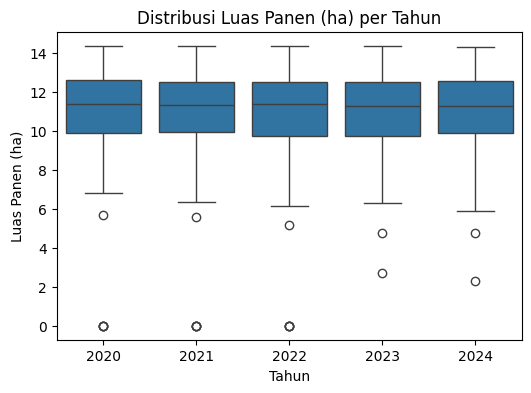

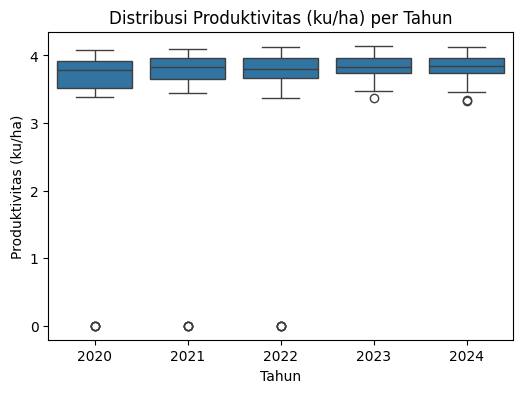

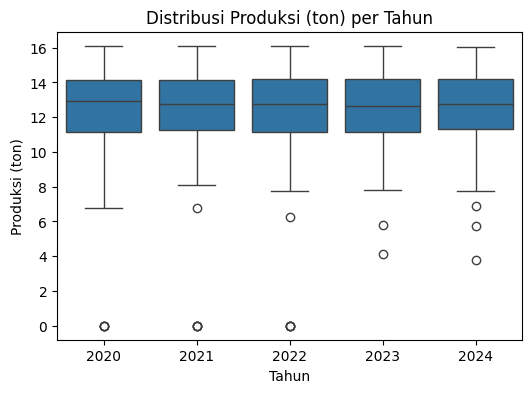

In [ ]:
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Tahun', y=feature, data=df)
    plt.title(f"Distribusi {feature} per Tahun")
    plt.show()

## Uji Asumsi Normal Multivariat

In [ ]:
# Pilih fitur numerik untuk diuji
data = df[features].values

# Hitung mean dan matriks kovarians
mean_vec = np.mean(data, axis=0)
cov_matrix = np.cov(data, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Hitung jarak Mahalanobis untuk setiap observasi
mahalanobis_distances = [mahalanobis(row, mean_vec, inv_cov_matrix) for row in data]

# Uji Mardia (Skewness dan Kurtosis)
n, p = data.shape
skewness = (1/n) * sum((d**3 for d in mahalanobis_distances))
kurtosis = (1/n) * sum((d**2 for d in mahalanobis_distances)) - p * (p + 2)

# Hitung p-value berdasarkan distribusi chi-square
df_skew = p * (p + 1) * (p + 2) / 6
df_kurt = p * (p + 1) / 2

p_skew = 1 - chi2.cdf(skewness, df=df_skew)
p_kurt = 1 - chi2.cdf(kurtosis, df=df_kurt)

# Hasil
print(f"Mardia's Skewness: {skewness:.4f}, p-value: {p_skew:.4f}")
print(f"Mardia's Kurtosis: {kurtosis:.4f}, p-value: {p_kurt:.4f}")

# Interpretasi
if p_skew < 0.05 or p_kurt < 0.05:
    print("Tolak H₀: Data tidak berdistribusi normal multivariat.")
else:
    print("Gagal tolak H₀: Data mengikuti distribusi normal multivariat.")

Mardia's Skewness: 8.1700, p-value: 0.6122
Mardia's Kurtosis: -12.0158, p-value: 1.0000
Gagal tolak H₀: Data mengikuti distribusi normal multivariat.


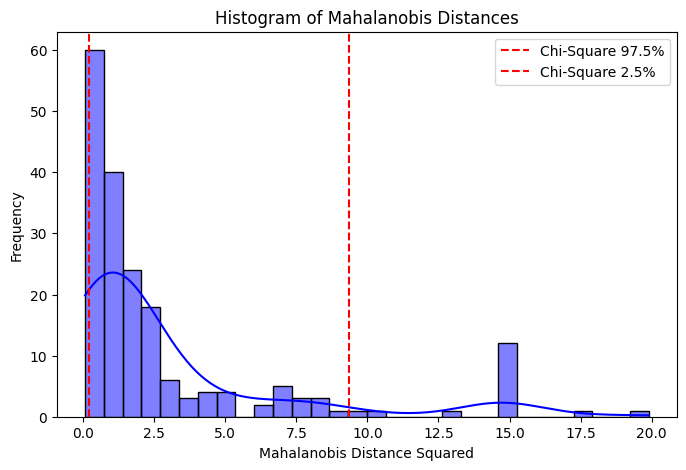

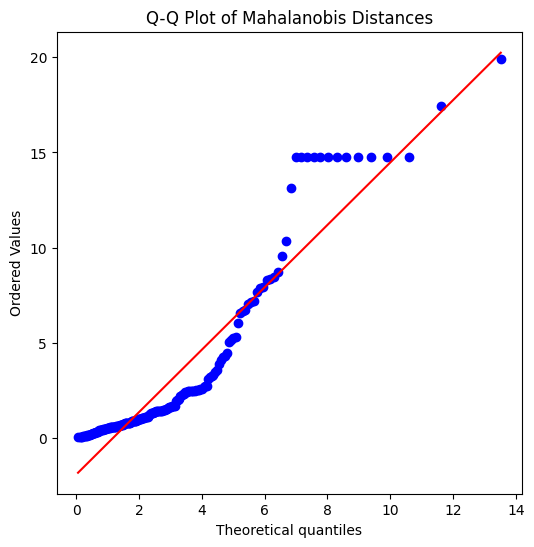

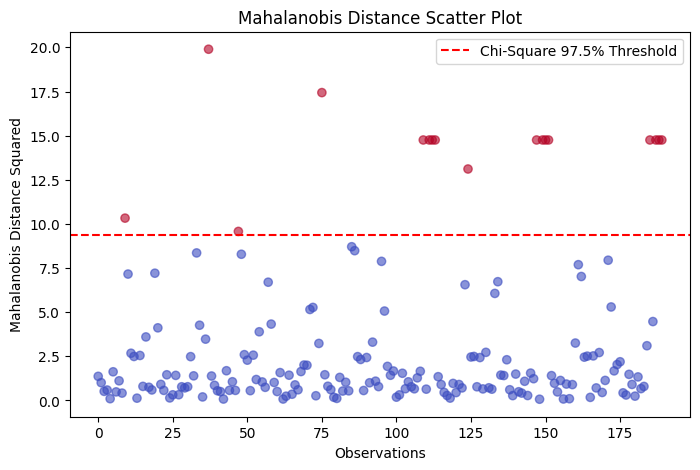

In [ ]:
# Pilih fitur numerik untuk diuji
data = df[features].values

# Hitung mean dan matriks kovarians
mean_vec = np.mean(data, axis=0)
cov_matrix = np.cov(data, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Hitung jarak Mahalanobis untuk setiap observasi
mahalanobis_distances = np.array([mahalanobis(row, mean_vec, inv_cov_matrix) for row in data])
mahalanobis_sq = mahalanobis_distances**2

# Visualisasi 1: Histogram Jarak Mahalanobis
plt.figure(figsize=(8,5))
sns.histplot(mahalanobis_sq, bins=30, kde=True, color='blue')
plt.axvline(x=chi2.ppf(0.975, df=data.shape[1]), color='red', linestyle='--', label="Chi-Square 97.5%")
plt.axvline(x=chi2.ppf(0.025, df=data.shape[1]), color='red', linestyle='--', label="Chi-Square 2.5%")
plt.xlabel('Mahalanobis Distance Squared')
plt.ylabel('Frequency')
plt.title('Histogram of Mahalanobis Distances')
plt.legend()
plt.show()

# Visualisasi 2: Q-Q Plot terhadap Distribusi Chi-Square
plt.figure(figsize=(6,6))
stats.probplot(mahalanobis_sq, dist="chi2", sparams=(data.shape[1],), plot=plt)
plt.title('Q-Q Plot of Mahalanobis Distances')
plt.show()

# Visualisasi 3: Scatter plot untuk outlier detection
plt.figure(figsize=(8,5))
plt.scatter(range(len(mahalanobis_sq)), mahalanobis_sq, c=(mahalanobis_sq > chi2.ppf(0.975, df=data.shape[1])), cmap='coolwarm', alpha=0.6)
plt.axhline(y=chi2.ppf(0.975, df=data.shape[1]), color='red', linestyle='--', label='Chi-Square 97.5% Threshold')
plt.xlabel('Observations')
plt.ylabel('Mahalanobis Distance Squared')
plt.title('Mahalanobis Distance Scatter Plot')
plt.legend()
plt.show()

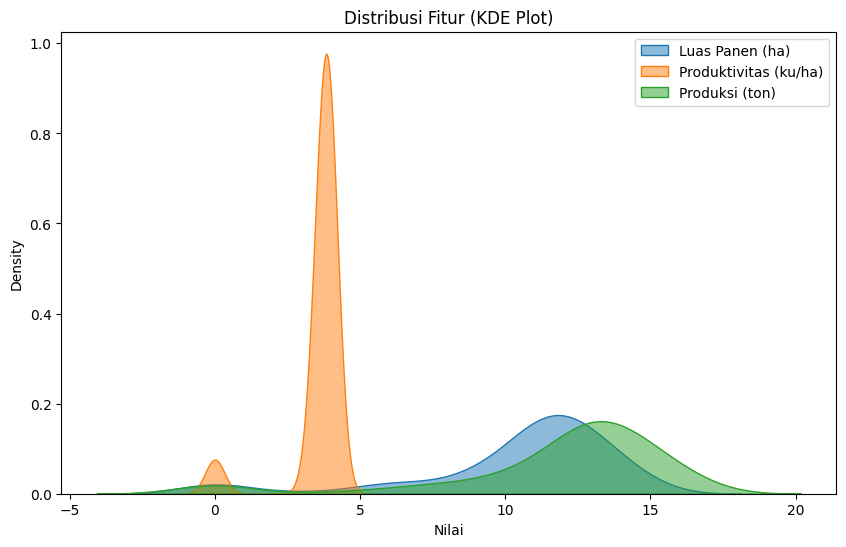

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for col in features:
    sns.kdeplot(df[col], fill=True, label=col, alpha=0.5)
plt.title("Distribusi Fitur (KDE Plot)")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

## Uji Asumsi Homogenitas Varians

In [ ]:
# prompt: uji homogenitas data

# ... (your existing code for data loading and preprocessing)

# Uji Bartlett
# ... (your existing Bartlett test code)

# Uji Box's M
# ... (your existing Box's M test code)

# Uji Mardia
# ... (your existing Mardia's test code)


#Uji Levene
#Group data by 'Tahun'
grouped = df.groupby('Tahun')

#Perform Levene's test for each numerical feature
for feature in features:
    levene_result = stats.levene(*[group[feature] for name, group in grouped])

    print(f"\nLevene's test for {feature}:")
    print(f"Statistic: {levene_result.statistic:.4f}")
    print(f"P-value: {levene_result.pvalue:.4f}")

    if levene_result.pvalue < 0.05:
      print("Tolak H0: Varians antar kelompok tidak homogen.")
    else:
      print("Gagal tolak H0: Varians antar kelompok homogen.")



Levene's test for Luas Panen (ha):
Statistic: 0.4459
P-value: 0.7753
Gagal tolak H0: Varians antar kelompok homogen.

Levene's test for Produktivitas (ku/ha):
Statistic: 2.3462
P-value: 0.0562
Gagal tolak H0: Varians antar kelompok homogen.

Levene's test for Produksi (ton):
Statistic: 0.5708
P-value: 0.6841
Gagal tolak H0: Varians antar kelompok homogen.


## MANOVA One-Way

One-Way karena var independennya 1. Tujuannya adalah melihat apakah Tahun (2023 vs 2024) secara simultan berpengaruh signifikan terhadap Luas Panen (ha), Produktivitas (ku/ha), dan Produksi (ton).

In [ ]:
# Install paket yang diperlukan
#!pip install numpy pandas scipy statsmodels

In [ ]:
# Import library
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.multivariate.manova import MANOVA
from scipy.stats import f

In [ ]:
# --- One-Way MANOVA ---
print("\n=== One-Way MANOVA ===")
manova_oneway = MANOVA.from_formula('Q("Luas Panen (ha)") + Q("Produktivitas (ku/ha)") + Q("Produksi (ton)") ~ Tahun', data=df)
result_oneway = manova_oneway.mv_test()
print(result_oneway)

# Debugging: Periksa hasil lengkap MANOVA untuk mendapatkan struktur yang benar
print("\nKunci hasil MANOVA One-Way:", result_oneway.results.keys())

# Coba akses p-value secara benar
try:
    # Periksa struktur dictionary
    stat_result = result_oneway.results['Tahun']
    print("\nStruktur hasil untuk 'Tahun':", stat_result)

    # Coba Wilks' Lambda
    wilks_lambda_result = stat_result['stat']
    print("\nStruktur hasil untuk 'stat':", wilks_lambda_result)

    # Ambil p-value dari Wilks' Lambda
    p_value_oneway = wilks_lambda_result.iloc[0, -1]  # P-value berada di kolom terakhir
    print("\nP-value dari Wilks' Lambda:", p_value_oneway)

except KeyError as e:
    print(f"⚠️ KeyError terjadi: {e}. Pastikan kunci yang benar tersedia.")
    p_value_oneway = None

# Keputusan One-Way MANOVA
if p_value_oneway is not None and p_value_oneway < 0.05:
    print("Tolak H₀: Terdapat perbedaan signifikan antar tahun dalam setidaknya satu variabel dependen.")
else:
    print("Gagal menolak H₀: Tidak ada perbedaan signifikan antar tahun.")


=== One-Way MANOVA ===
                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9369 3.0000 186.0000  4.1777 0.0069
         Pillai's trace 0.0631 3.0000 186.0000  4.1777 0.0069
 Hotelling-Lawley trace 0.0674 3.0000 186.0000  4.1777 0.0069
    Roy's greatest root 0.0674 3.0000 186.0000  4.1777 0.0069
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
         Tahun          Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9360 3.0000 186.0000  4.2428 0.0063
         Pillai's trace 0.0640 3.0000 186.0000  4.2428 0.0063
 H

## RM MANOVA one way - alternatif karena tidak independen

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA

# Menjalankan RM One-Way MANOVA
formula = 'Q("Luas Panen (ha)") + Q("Produktivitas (ku/ha)") + Q("Produksi (ton)") ~ Tahun'
rm_manova = MANOVA.from_formula(formula, data=df)
result_rm = rm_manova.mv_test()
print(result_rm)

# Mengakses p-value dari hasil MANOVA
try:
    p_value_tahun = result_rm.results['Tahun']['stat'].loc["Wilks' lambda", "Pr > F"]
except KeyError:
    print("⚠️ KeyError: Wilks' Lambda tidak ditemukan! Menggunakan metode alternatif.")
    p_value_tahun = result_rm.results['Tahun']['stat'].iloc[0, -1]  # Mengambil p-value dari kolom terakhir

# Keputusan RM One-Way MANOVA
if p_value_tahun < 0.05:
    print("Tolak H₀: Terdapat perbedaan signifikan berdasarkan faktor Tahun dalam repeated measures.")
else:
    print("Gagal menolak H₀: Tidak ada perbedaan signifikan berdasarkan faktor Tahun dalam repeated measures.")

                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9369 3.0000 186.0000  4.1777 0.0069
         Pillai's trace 0.0631 3.0000 186.0000  4.1777 0.0069
 Hotelling-Lawley trace 0.0674 3.0000 186.0000  4.1777 0.0069
    Roy's greatest root 0.0674 3.0000 186.0000  4.1777 0.0069
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
         Tahun          Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9360 3.0000 186.0000  4.2428 0.0063
         Pillai's trace 0.0640 3.0000 186.0000  4.2428 0.0063
 Hotelling-Lawley trace 0.

* Menunjukkan bahwa Tahun memiliki pengaruh signifikan terhadap variabel dependen (Luas Panen, Produktivitas, Produksi).
* Artinya, produksi pertanian berubah seiring waktu.

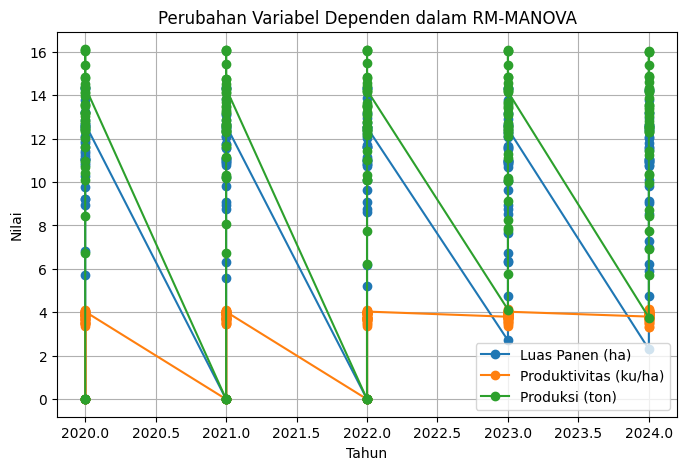

In [ ]:
# Visualisasi Profile Plot
plt.figure(figsize=(8, 5))
for col in df.columns[1:]:
    plt.plot(df["Tahun"], df[col], marker='o', label=col)

plt.xlabel("Tahun")
plt.ylabel("Nilai")
plt.title("Perubahan Variabel Dependen dalam RM-MANOVA")
plt.legend()
plt.grid()
plt.show()

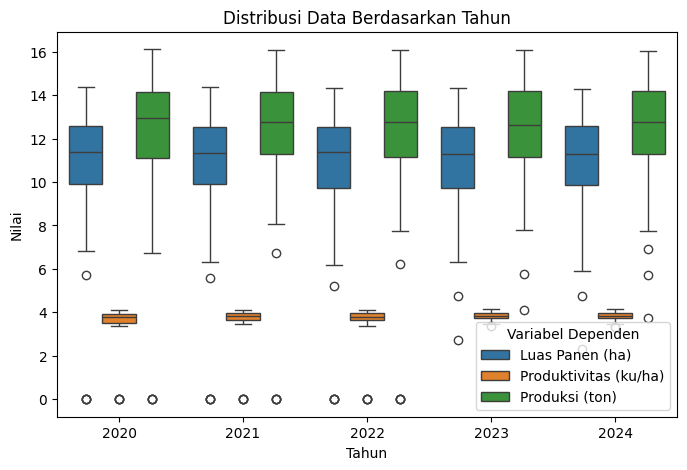

In [ ]:
# Mengubah data menjadi format long untuk seaborn
df_long = df.melt(id_vars=["Tahun"], var_name="Variabel", value_name="Nilai")

plt.figure(figsize=(8, 5))
sns.boxplot(x="Tahun", y="Nilai", hue="Variabel", data=df_long)
plt.title("Distribusi Data Berdasarkan Tahun")
plt.xlabel("Tahun")
plt.ylabel("Nilai")
plt.legend(title="Variabel Dependen")
plt.show()

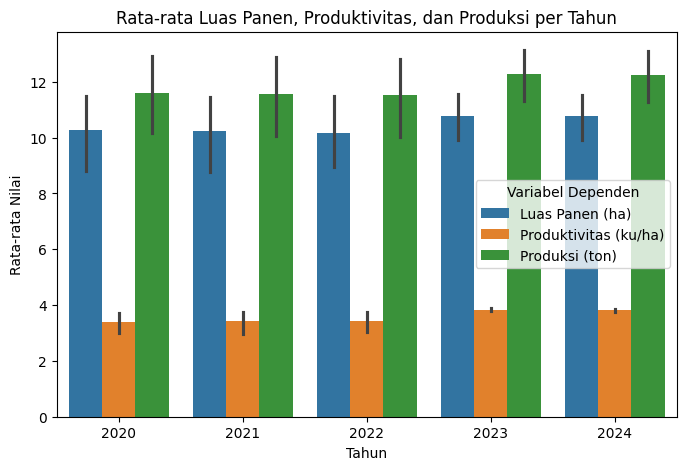

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Tahun", y="Nilai", hue="Variabel", data=df_long)
plt.title("Rata-rata Luas Panen, Produktivitas, dan Produksi per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Nilai")
plt.legend(title="Variabel Dependen")
plt.show()